In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('Cleaned_data.csv')
print(data.shape)

(2520798, 79)


In [2]:
print(data['Label'].value_counts())
print("No of Unique :",data['Label'].nunique())

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
No of Unique : 15


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

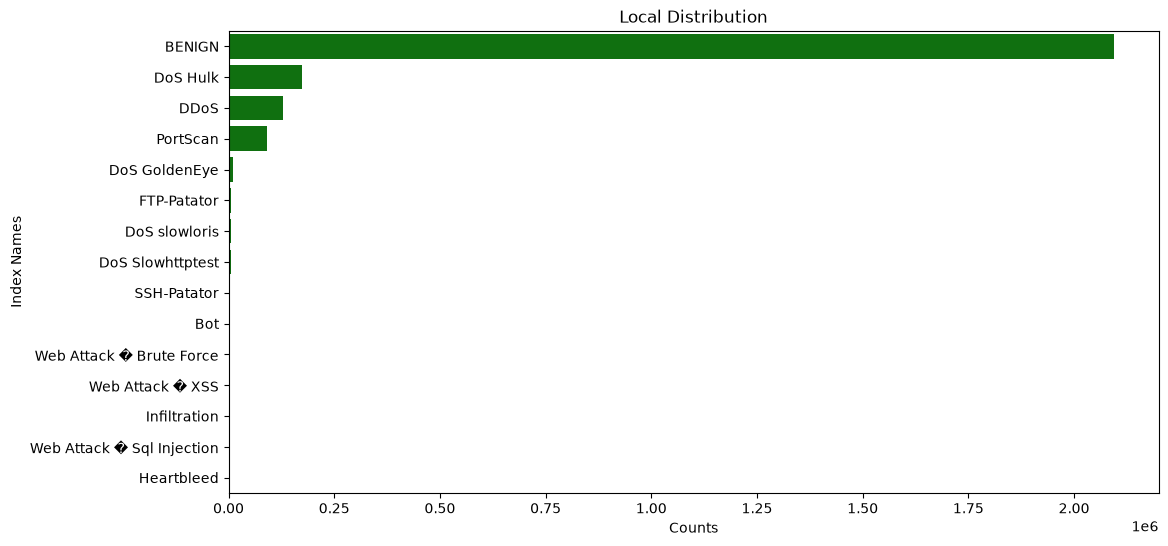

In [4]:
label_counts = data['Label'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x = label_counts.values, y = label_counts.index,color = 'green')
plt.title('Local Distribution')
plt.ylabel('Index Names')
plt.xlabel('Counts')
plt.show()

### We see that Bening attacks are too dominating , so dataset is imbalanced ... later we can use SMOTE

In [8]:
total = label_counts.sum()
for label,count in label_counts.items():
    pct = (count / total) * 100
    print(label ,round(pct,3) ,'%')

BENIGN 83.111 %
DoS Hulk 6.857 %
DDoS 5.078 %
PortScan 3.598 %
DoS GoldenEye 0.408 %
FTP-Patator 0.235 %
DoS slowloris 0.214 %
DoS Slowhttptest 0.207 %
SSH-Patator 0.128 %
Bot 0.077 %
Web Attack � Brute Force 0.058 %
Web Attack � XSS 0.026 %
Infiltration 0.001 %
Web Attack � Sql Injection 0.001 %
Heartbleed 0.0 %


Binary_Label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64


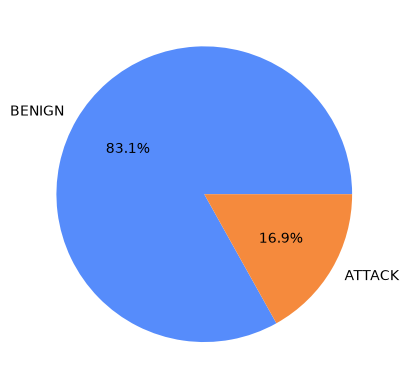

In [14]:
data['Binary_Label'] = data['Label'].apply(lambda x:'BENIGN' if x == 'BENIGN' else 'ATTACK')
counts = data['Binary_Label'].value_counts()
print(counts)


plt.pie(counts,labels=counts.index,autopct = '%1.1f%%')
plt.show()


In [16]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8.690590e+03,1.901280e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2520798.0,1.659161e+07,3.523276e+07,-13.0,208.0,50622.0,5333340.5,119999998.0
Total Fwd Packets,2520798.0,1.028174e+01,7.944201e+02,1.0,2.0,2.0,6.0,219759.0
Total Backward Packets,2520798.0,1.157280e+01,1.056922e+03,0.0,1.0,2.0,5.0,291922.0
Total Length of Fwd Packets,2520798.0,6.119477e+02,1.058827e+04,0.0,12.0,66.0,332.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2520798.0,6.546359e+04,6.111585e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2520798.0,9.337367e+06,2.484818e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2520798.0,5.657941e+05,4.874169e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2520798.0,9.763770e+06,2.561746e+07,0.0,0.0,0.0,0.0,120000000.0


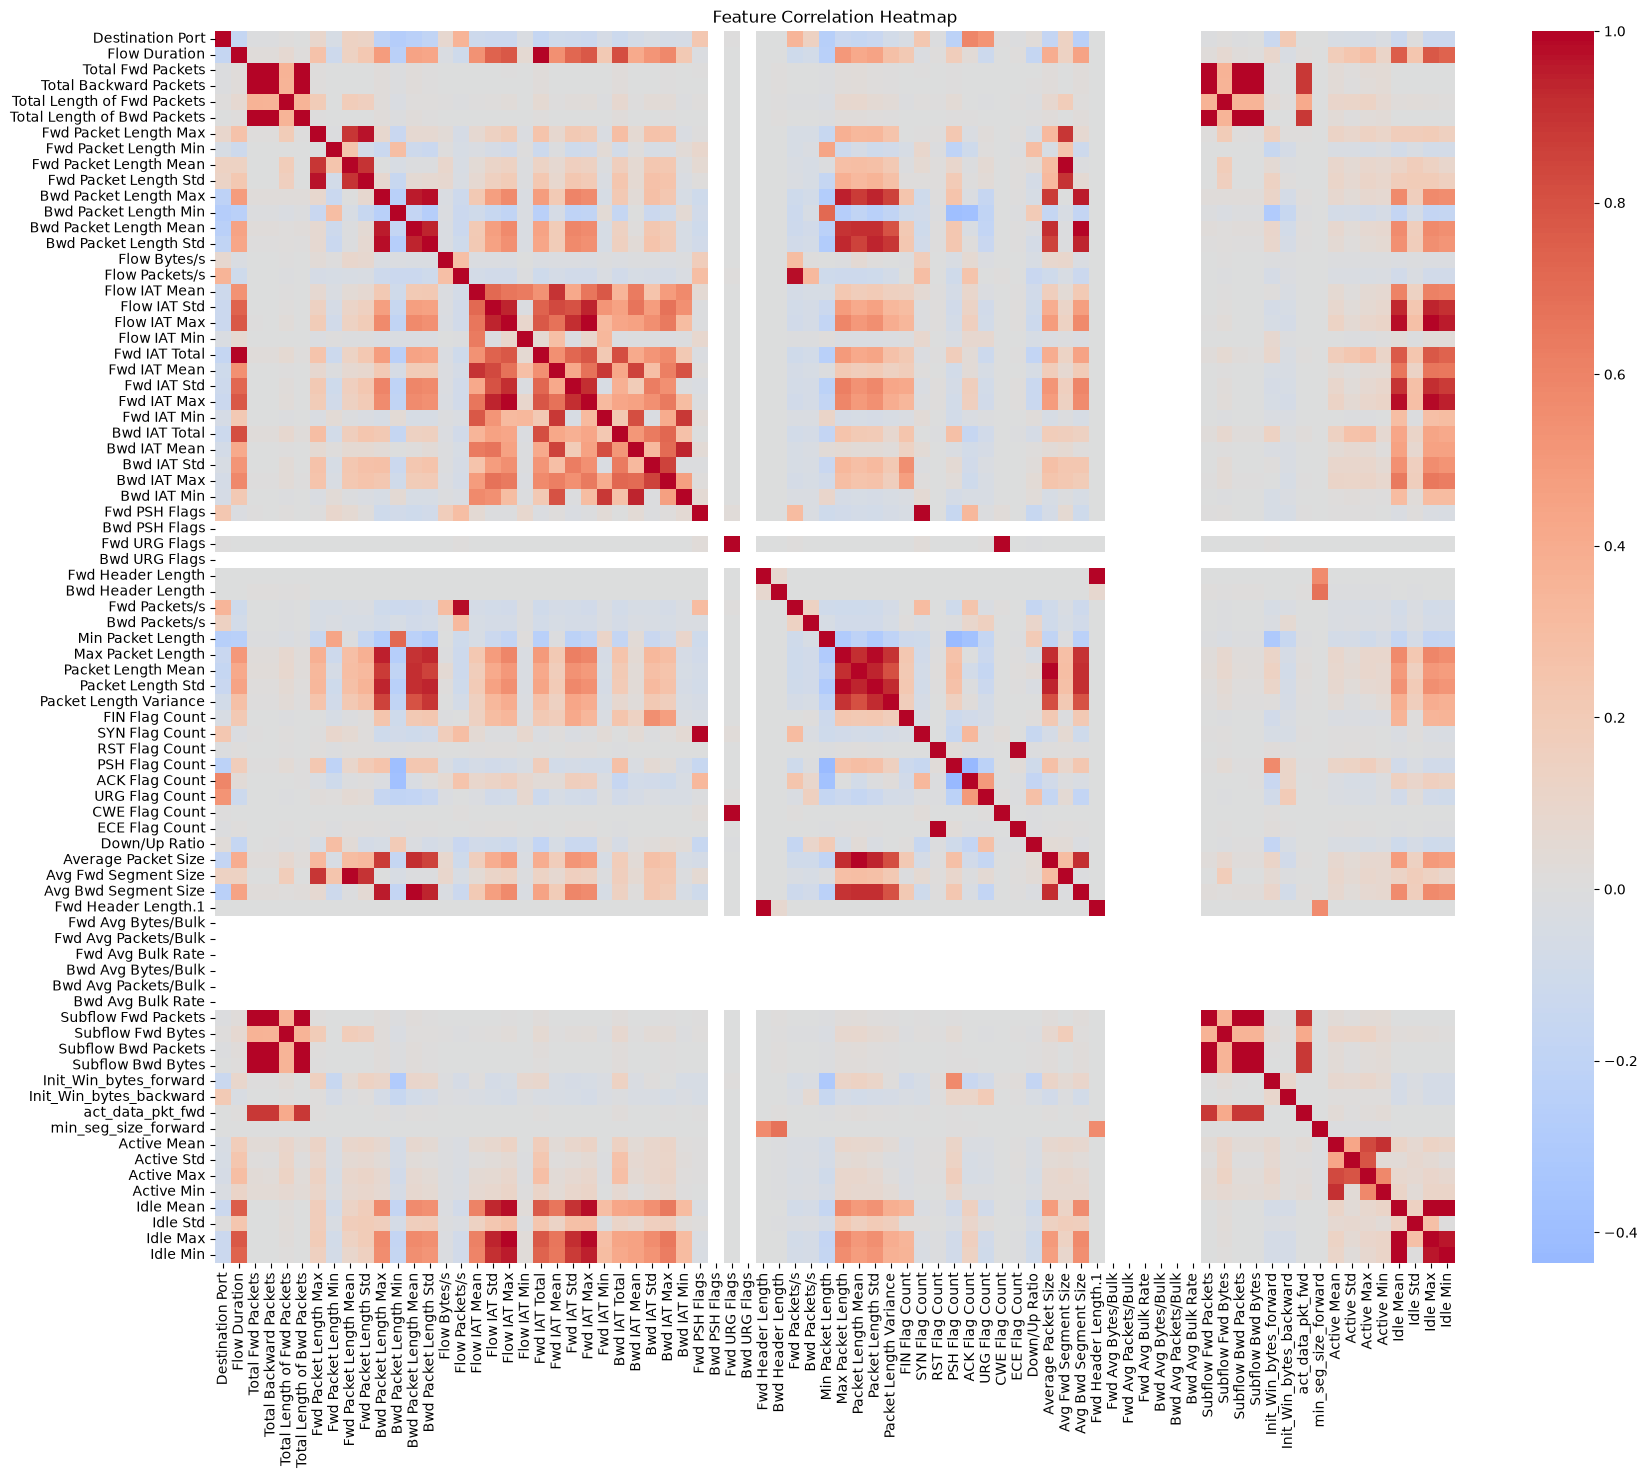

In [24]:
numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    cmap = 'coolwarm',
    center = 0
)
plt.title('Feature Correlation Heatmap')

plt.show()

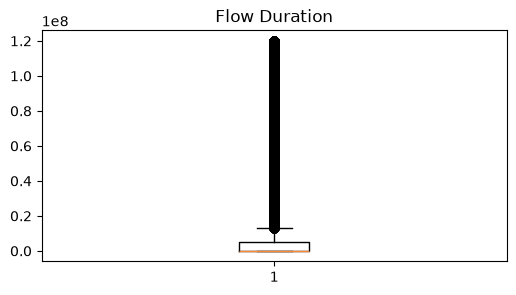

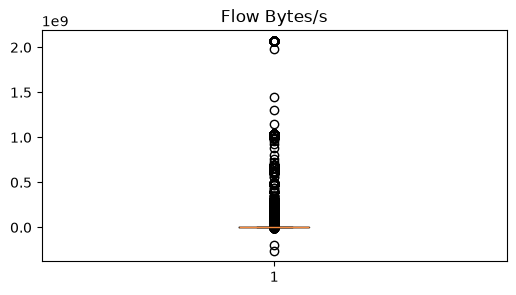

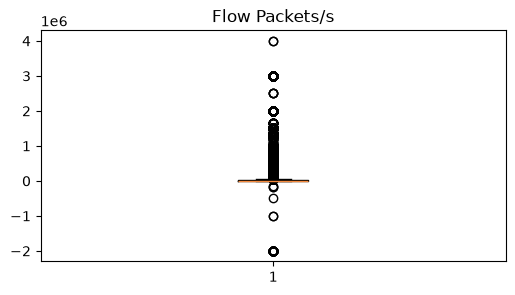

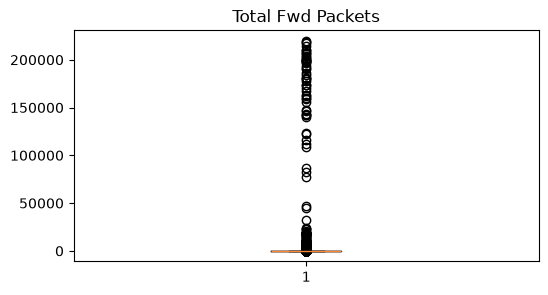

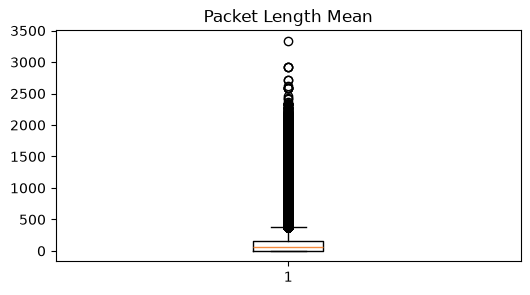

In [32]:
features = ['Flow Duration', 'Flow Bytes/s','Flow Packets/s', 'Total Fwd Packets','Packet Length Mean']

for feature in features:
    plt.figure(figsize=(6,3))
    plt.boxplot(data[feature])
    plt.title(feature)
    plt.show()